In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline

In [2]:
correlations = pd.read_csv('./task_survey_correlations.csv')

In [6]:
correlations.score.unique()

array(['baars', 'phq8', 'gad7', 'hitop', 'baars_hyperactivity',
       'baars_impulsivity', 'baars_inattentive', 'baars_sct',
       'hitop_anhdep', 'hitop_sepinsec', 'hitop_anxwor', 'hitop_welbe',
       'hitop_appgn', 'hitop_socanx', 'hitop_hypsom', 'hitop_cogprb',
       'hitop_indec', 'hitop_appls', 'hitop_insom', 'hitop_shmglt'],
      dtype=object)

In [21]:
init_clust_score_order = {
    'phq8': 'PHQ-8',
    'gad7': 'GAD-7',
    'hitop': 'HiTOP Total',
    'baars': 'BAARS total',
    'baars_hyperactivity': 'B-Hyper.',
    'baars_inattentive': 'B-Inatt.',
    'baars_impulsivity': 'B-Impuls.',
    'baars_sct': 'B-SCT',
    'hitop_anhdep': 'Anh. Dep.',
    'hitop_anxwor': 'Anx. Wor.',
    'hitop_appgn': 'App. Gain',
    'hitop_appls': 'App. Loss',
    'hitop_cogprb': 'Cog. Prob.',
    'hitop_hypsom': 'Hyposom.',
    'hitop_indec': 'Indecis.',
    'hitop_insom': 'Insom.',
    'hitop_socanx': 'Soc. Anx.',
    'hitop_shmglt': 'Shame/Glt.',
    'hitop_sepinsec': 'Sep. Insec.',
    'hitop_welbe': 'Well Being',
}
init_clust_param_order = {
    'rdm__t0': 'RDM- $t_0$',
    'rdm__v0': 'RDM- $v_0$',
    'rdm__w_d': 'RDM- $\\omega_d$',
    'rdm__w_s': 'RDM- $\\omega_s$',
    'rdm__sigma': 'RDM- $\\sigma$',
    'rdm__sigma_timer': 'RDM- $\\sigma_t$',
    'rdm__v_timer': 'RDM- $v_t$',
    
    'flkr__t0': 'FLKR- $t_0$',
    'flkr__thresh': 'FLKR- $\\alpha$',
    'flkr__L': 'FLKR- $\\beta$',
    'flkr__K': 'FLKR- $\\kappa$',
    'flkr__sd0': 'FLKR- $sd_0$',
    'flkr__p': 'FLKR- $p$',
    'flkr__r': 'FLKR- $r_d$',
    'flkr__alpha': 'FLKR- $n_0$',
    
    'cab__kappa': 'CAB- $\\kappa$',
    'cab__gamma': 'CAB- $\\gamma$',
    'cab__tau': 'CAB- $\\tau$',
    'cab__rho': 'CAB- $\\rho$',
    'cab__nu': 'CAB- $\\nu$',
    'cab__lam': 'CAB- $\\lambda$',
    'cab__alpha': 'CAB- $\\alpha$',
    'cab__a': 'CAB- $a$',
    'cab__w': 'CAB- $w$',
    'cab__t0': 'CAB- $t_0$',
    
    'bart__alpha': 'BART- $\\alpha$',
    'bart__gamma_pos': 'BART- $\\gamma +$',
    'bart__gamma_neg': 'BART- $\\gamma -$',
    'bart__theta': 'BART- $\\theta$',
    'bart__tau': 'BART- $\\tau$',
}

In [22]:
correlations['Parameter'] = correlations.task + correlations.parameter.str.replace('map','')
# drop Today
correlations = correlations.loc[~correlations.score.str.contains('today'), :].copy()
correlations['pr2'] = np.round(correlations.partial_r2 * 100, 1).astype(str)
correlations.loc[~correlations.hs_sig, 'pr2'] = ''
t_map = correlations.pivot(columns='score', index='Parameter', values='t')
pr2_map = correlations.pivot(columns='score', index='Parameter', values='pr2')
fdr_sig_map = correlations.pivot(columns='score', index='Parameter', values='fdr_sig')


In [23]:
t_map_plot = t_map.loc[init_clust_param_order.keys(), init_clust_score_order.keys()]
pr2_map_plot = pr2_map.loc[init_clust_param_order.keys(), init_clust_score_order.keys()]
t_map_plot = t_map_plot.rename(columns=init_clust_score_order, index=init_clust_param_order)
pr2_map_plot = pr2_map_plot.rename(columns=init_clust_score_order, index=init_clust_param_order)

<Axes: xlabel='Parameter', ylabel='score'>

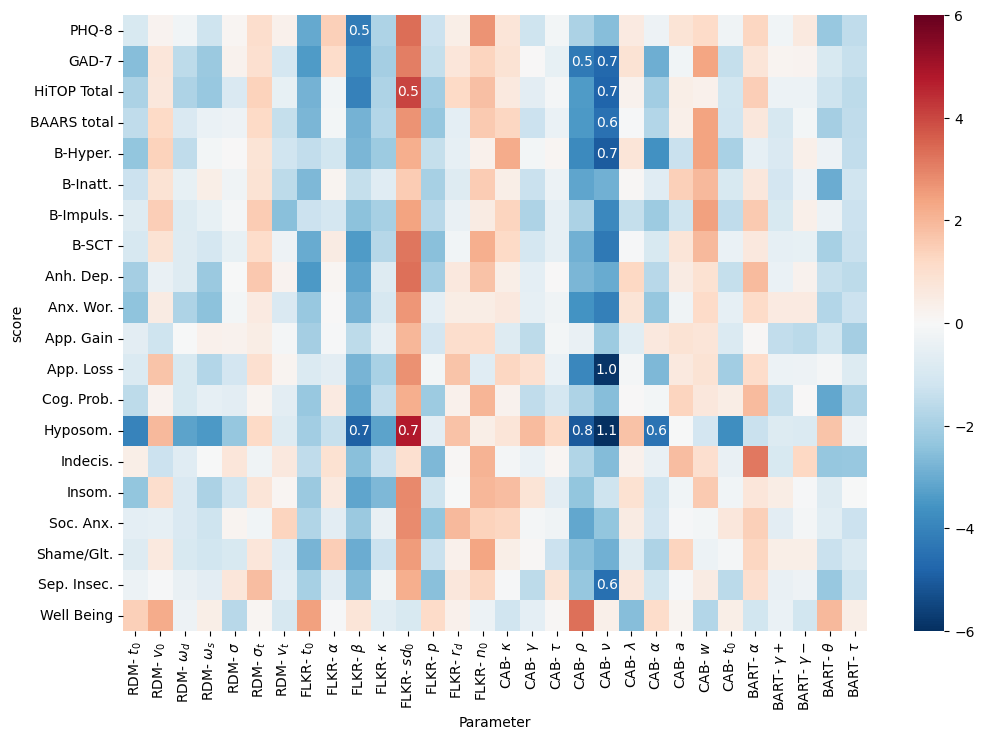

In [24]:
fig, ax = plt.subplots(1, figsize=(12,8))
sns.heatmap(t_map_plot.T,cmap='RdBu_r', vmin=-6, vmax=6, annot=pr2_map_plot.T, fmt='')

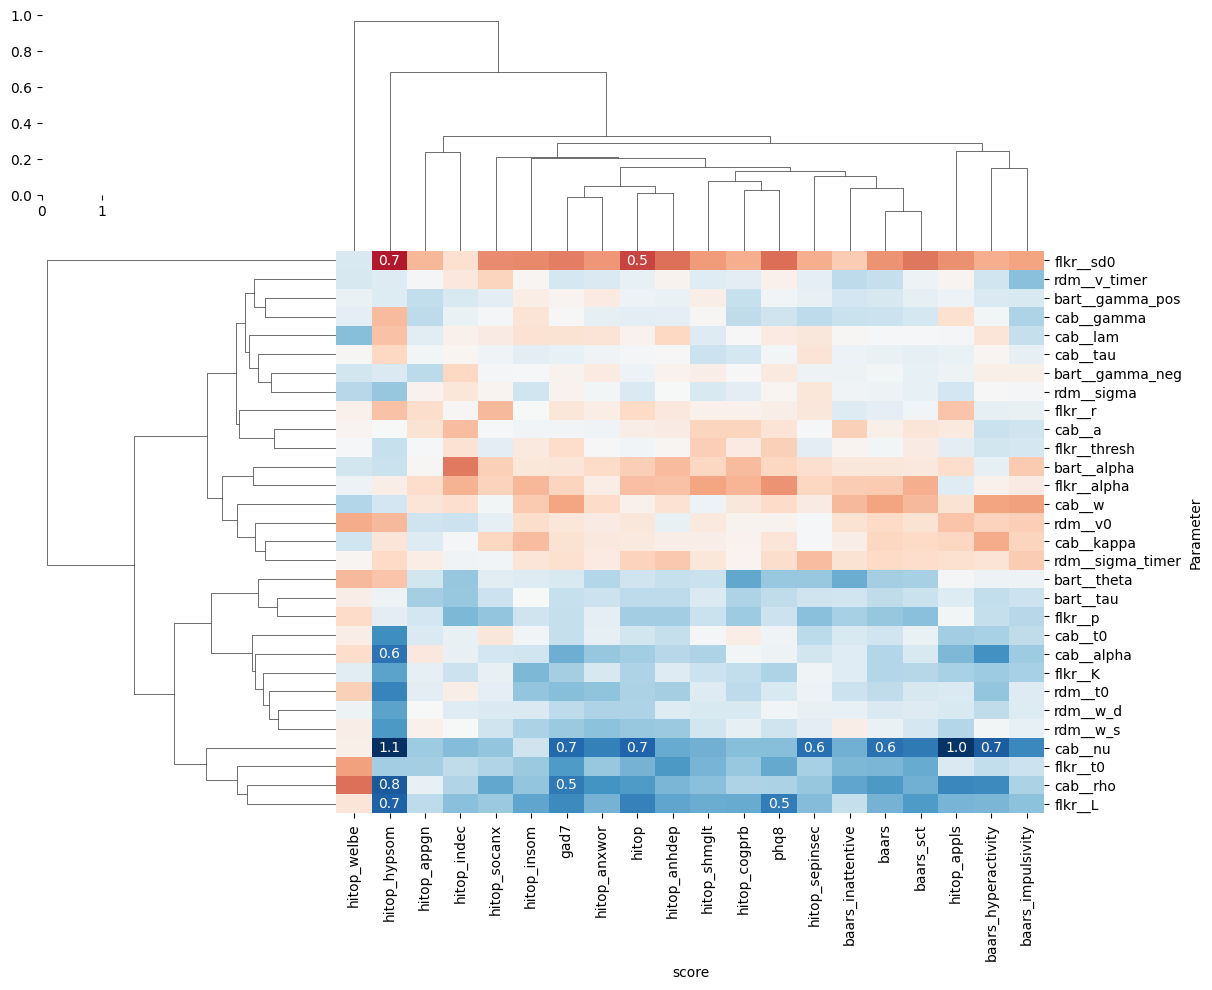

In [25]:
sns.clustermap(t_map, cmap='RdBu_r', vmin=-6, vmax=6, annot=pr2_map, fmt='', dendrogram_ratio=0.3, cbar=False, figsize=(12,10))

In [26]:
clust_param_order = {
    'flkr__sd0': 'FLKR- $sd_0$',
    'rdm__v_timer': 'RDM- $v_t$',
    'bart__gamma_pos': 'BART- $\\gamma +$',
    'cab__gamma': 'CAB- $\\gamma$',
    'cab__lam': 'CAB- $\\lambda$',
    'cab__tau': 'CAB- $\\tau$',
    'bart__gamma_neg': 'BART- $\\gamma -$',
    'rdm__sigma': 'RDM- $\\sigma$',
    'flkr__r': 'FLKR- $r_d$',
    'cab__a': 'CAB- $a$',
    'flkr__thresh': 'FLKR- $\\alpha$',
    'bart__alpha': 'BART- $\\alpha$',
    'flkr__alpha': 'FLKR- $n_0$',
    'cab__w': 'CAB- $w$',
    'rdm__v0': 'RDM- $v_0$',
    'cab__kappa': 'CAB- $\\kappa$',
    'rdm__sigma_timer': 'RDM- $\\sigma_t$',
    'bart__theta': 'BART- $\\theta$',
    'bart__tau': 'BART- $\\tau$',
    'flkr__p': 'FLKR- $p$',
    'cab__t0': 'CAB- $t_0$',
    'cab__alpha': 'CAB- $\\alpha$',
    'flkr__K': 'FLKR- $\\kappa$',
    'rdm__t0': 'RDM- $t_0$',
    'rdm__w_d': 'RDM- $\\omega_d$',
    'rdm__w_s': 'RDM- $\\omega_s$',
    'cab__nu': 'CAB- $\\nu$',
    'flkr__t0': 'FLKR- $t_0$',
    'cab__rho': 'CAB- $\\rho$',
    'flkr__L': 'FLKR- $\\beta$'
}
clust_score_order = {
    'hitop_welbe': 'Well Being',
    'hitop_hypsom': 'Hyposom.',
    'hitop_appgn': 'App. Gain',
    'hitop_indec': 'Indecis.',
    'hitop_socanx': 'Soc. Anx.',
    'hitop_insom': 'Insom.',
    'gad7': 'GAD-7',
    'hitop_anxwor': 'Anx. Wor.',
    'hitop': 'HiTOP Total',
    'hitop_anhdep': 'Anh. Dep.',
    'hitop_shmglt': 'Shame/Glt.',
    'hitop_cogprb': 'Cog. Prob.',
    'phq8': 'PHQ-8',
    'hitop_sepinsec': 'Sep. Insec.',
    'baars_inattentive': 'B-Inatt.',
    'baars': 'BAARS total',
    'baars_sct': 'B-SCT',
    'hitop_appls': 'App. Loss',
    'baars_hyperactivity': 'B-Hyper.',
    'baars_impulsivity': 'B-Impuls.'
}

In [27]:
t_map_plot = t_map.loc[clust_param_order.keys(), clust_score_order.keys()]
pr2_map_plot = pr2_map.loc[clust_param_order.keys(), clust_score_order.keys()]
t_map_plot = t_map_plot.rename(columns=clust_score_order, index=clust_param_order)
pr2_map_plot = pr2_map_plot.rename(columns=clust_score_order, index=clust_param_order)

<Axes: xlabel='Parameter', ylabel='score'>

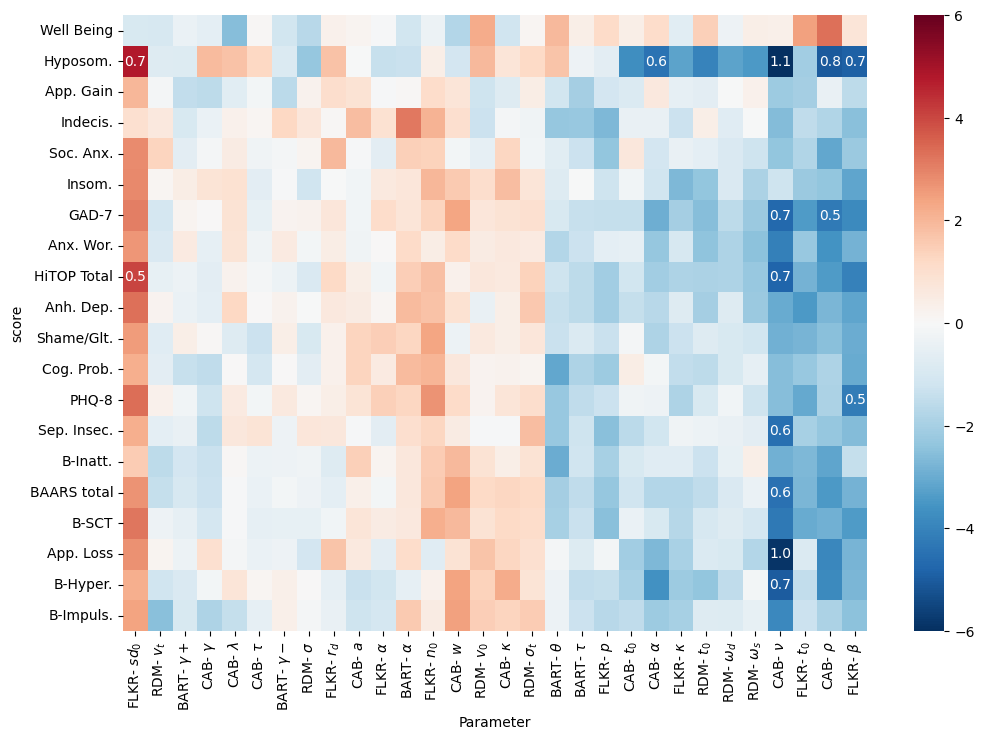

In [28]:
fig, ax = plt.subplots(1, figsize=(12,8))
sns.heatmap(t_map_plot.T,cmap='RdBu_r', vmin=-6, vmax=6, annot=pr2_map_plot.T, fmt='')